# Metaheuristic Feature Engineering

This notebook implements Genetic Algorithm-based feature engineering for financial markets. We'll create new technical indicators by optimizing their parameters to maximize predictive power while maintaining time-series integrity.

## Features to Engineer:
1. **Adaptive Moving Average (AMA)** - Volatility-adjusted moving average
2. **Fractal Dimension Indicator (FDI)** - Market roughness measurement

## Workflow:
1. Load existing engineered features
2. Run GA optimization for new features  
3. Add optimized features to dataset
4. Save updated feature set for model training

In [6]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Import our custom feature engineering module
from MH_Feature_Engineering import (
    engineer_adaptive_moving_average, 
    engineer_fractal_dimension_indicator,
    FeatureEngineeringGA
)

print("Libraries imported successfully!")
print("Feature Engineering GA module loaded!")

# Set display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

Libraries imported successfully!
Feature Engineering GA module loaded!


In [7]:
# Load existing engineered features
print("Loading existing engineered features...")
data = pd.read_csv('raw_data/engineered_features.csv')

print(f"Data shape: {data.shape}")
print(f"Date range: {data.index[0] if hasattr(data.index, '__getitem__') else 'Index not available'} to {data.index[-1] if hasattr(data.index, '__getitem__') else 'Index not available'}")
print("\nExisting features:")
print(data.columns.tolist()[:20], "...")  # Show first 20 features

# Check for required columns
required_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'Bullish']
missing_cols = [col for col in required_cols if col not in data.columns]
if missing_cols:
    print(f"\nWarning: Missing required columns: {missing_cols}")
else:
    print("\nAll required columns found!")

# Basic data validation
print(f"\nData validation:")
print(f"Null values: {data.isnull().sum().sum()}")
print(f"Infinite values: {np.isinf(data.select_dtypes(include=[np.number])).sum().sum()}")

# Display basic statistics
print("\nBasic statistics for OHLCV data:")
print(data[['Open', 'High', 'Low', 'Close', 'Volume']].describe())

Loading existing engineered features...
Data shape: (3181, 113)
Date range: 0 to 3180

Existing features:
['Open', 'High', 'Low', 'Close', 'Volume', 'Percentage_Change', 'Log_Return', 'Price_Diff', 'Open_Close_Diff', 'High_Low_Diff', 'High_Close_Ratio', 'Low_Close_Ratio', 'Open_Close_Ratio', 'Candle_Range', 'Body_Size', 'Upper_Shadow', 'Lower_Shadow', 'Body_To_Range_Ratio', 'Bullish', 'SMA_5'] ...

All required columns found!

Data validation:
Null values: 1828
Infinite values: 0

Basic statistics for OHLCV data:
              Open         High          Low        Close        Volume
count  3181.000000  3181.000000  3181.000000  3181.000000   3181.000000
mean      1.127669     1.128591     1.126823     1.127709   6726.952531
std       0.038957     0.038933     0.038965     0.038939   5339.126935
min       1.036340     1.037360     1.035970     1.036340    170.000000
25%       1.092930     1.093780     1.091880     1.093060   3170.000000
50%       1.136880     1.137910     1.135910     

## 1. Adaptive Moving Average (AMA) Engineering

The Adaptive Moving Average adjusts its smoothing factor based on market volatility and directional movement. This makes it more responsive during trending markets and less sensitive during ranging markets.

**GA Optimization Parameters:**
- `smoothing_factor`: Base smoothing rate (0.01-0.9)
- `volatility_window`: Lookback period for volatility calculation (5-50)
- `fast_period`: Fast EMA period for efficiency ratio (2-10)
- `slow_period`: Slow EMA period for efficiency ratio (10-50)

In [8]:
# Engineer Adaptive Moving Average using GA optimization
print("=" * 60)
print("ENGINEERING ADAPTIVE MOVING AVERAGE (AMA)")
print("=" * 60)

# Prepare target variable
target = data['Bullish']
print(f"Target distribution: {target.value_counts().to_dict()}")

# Configure GA parameters for AMA
ga_params_ama = {
    'pop_size': 30,           # Smaller for faster execution
    'max_generations': 20,     # Fewer generations for testing
    'crossover_rate': 0.8,
    'mutation_rate': 0.2,
    'cv_folds': 3,            # Fewer folds for faster execution
    'random_state': 42
}

print(f"\nGA Parameters for AMA: {ga_params_ama}")

# Run GA optimization for AMA
start_time = datetime.now()
print(f"\nStarting AMA optimization at {start_time.strftime('%H:%M:%S')}")

try:
    ama_feature, ama_details = engineer_adaptive_moving_average(
        data, target, **ga_params_ama
    )
    
    end_time = datetime.now()
    duration = (end_time - start_time).total_seconds()
    
    print(f"\nAMA optimization completed in {duration:.1f} seconds")
    print(f"Best fitness achieved: {ama_details['best_fitness']:.4f}")
    print(f"Optimized parameters:")
    for param_name, value in zip(ama_details['parameter_names'], ama_details['best_parameters']):
        print(f"  {param_name}: {value:.4f}" if isinstance(value, float) else f"  {param_name}: {value}")
    
    # Add AMA feature to dataset
    feature_name = 'AMA_GA_Optimized'
    data[feature_name] = ama_feature
    
    print(f"\nAMA feature '{feature_name}' added to dataset")
    print(f"Feature statistics:")
    print(f"  Mean: {ama_feature.mean():.6f}")
    print(f"  Std:  {ama_feature.std():.6f}")
    print(f"  Min:  {ama_feature.min():.6f}")
    print(f"  Max:  {ama_feature.max():.6f}")
    print(f"  Null values: {ama_feature.isnull().sum()}")
    
except Exception as e:
    print(f"Error in AMA optimization: {str(e)}")
    ama_feature = None
    ama_details = None

ENGINEERING ADAPTIVE MOVING AVERAGE (AMA)
Target distribution: {1: 1631, 0: 1550}

GA Parameters for AMA: {'pop_size': 30, 'max_generations': 20, 'crossover_rate': 0.8, 'mutation_rate': 0.2, 'cv_folds': 3, 'random_state': 42}

Starting AMA optimization at 10:59:32
Starting GA Feature Engineering for AMA
Population: 30, Generations: 20
------------------------------------------------------------
Generation   0: Best=0.4947, Avg=0.4947
Generation   0: Best=0.4947, Avg=0.4947
Generation   5: Best=0.4947, Avg=0.4947
Generation   5: Best=0.4947, Avg=0.4947
Generation  10: Best=0.4947, Avg=0.4947
Generation  10: Best=0.4947, Avg=0.4947
Generation  15: Best=0.4947, Avg=0.4947
Generation  15: Best=0.4947, Avg=0.4947
------------------------------------------------------------
GA completed! Best fitness: 0.4947
Best parameters: [0.17392087600646622, 15, 10, 50]

AMA optimization completed in 62.3 seconds
Best fitness achieved: 0.4947
Optimized parameters:
  smoothing_factor: 0.1739
  volatility

## 2. Fractal Dimension Indicator (FDI) Engineering

The Fractal Dimension Indicator measures the "roughness" or complexity of price movements. It helps distinguish between trending markets (lower FDI values) and ranging/choppy markets (higher FDI values).

**GA Optimization Parameters:**
- `window_size`: Number of periods for calculation (10-100)
- `high_low_factor`: Weight for high-low range in calculation (0.1-2.0)
- `scaling_factor`: Scaling factor for final dimension value (0.5-2.0)

In [9]:
# Engineer Fractal Dimension Indicator using GA optimization
print("=" * 60)
print("ENGINEERING FRACTAL DIMENSION INDICATOR (FDI)")
print("=" * 60)

# Configure GA parameters for FDI
ga_params_fdi = {
    'pop_size': 30,           # Smaller for faster execution
    'max_generations': 20,     # Fewer generations for testing
    'crossover_rate': 0.8,
    'mutation_rate': 0.2,
    'cv_folds': 3,            # Fewer folds for faster execution
    'random_state': 42
}

print(f"GA Parameters for FDI: {ga_params_fdi}")

# Run GA optimization for FDI
start_time = datetime.now()
print(f"\nStarting FDI optimization at {start_time.strftime('%H:%M:%S')}")

try:
    fdi_feature, fdi_details = engineer_fractal_dimension_indicator(
        data, target, **ga_params_fdi
    )
    
    end_time = datetime.now()
    duration = (end_time - start_time).total_seconds()
    
    print(f"\nFDI optimization completed in {duration:.1f} seconds")
    print(f"Best fitness achieved: {fdi_details['best_fitness']:.4f}")
    print(f"Optimized parameters:")
    for param_name, value in zip(fdi_details['parameter_names'], fdi_details['best_parameters']):
        print(f"  {param_name}: {value:.4f}" if isinstance(value, float) else f"  {param_name}: {value}")
    
    # Add FDI feature to dataset
    feature_name = 'FDI_GA_Optimized'
    data[feature_name] = fdi_feature
    
    print(f"\nFDI feature '{feature_name}' added to dataset")
    print(f"Feature statistics:")
    print(f"  Mean: {fdi_feature.mean():.6f}")
    print(f"  Std:  {fdi_feature.std():.6f}")
    print(f"  Min:  {fdi_feature.min():.6f}")
    print(f"  Max:  {fdi_feature.max():.6f}")
    print(f"  Null values: {fdi_feature.isnull().sum()}")
    
except Exception as e:
    print(f"Error in FDI optimization: {str(e)}")
    fdi_feature = None
    fdi_details = None

ENGINEERING FRACTAL DIMENSION INDICATOR (FDI)
GA Parameters for FDI: {'pop_size': 30, 'max_generations': 20, 'crossover_rate': 0.8, 'mutation_rate': 0.2, 'cv_folds': 3, 'random_state': 42}

Starting FDI optimization at 11:00:34
Starting GA Feature Engineering for FDI
Population: 30, Generations: 20
------------------------------------------------------------
Generation   0: Best=0.5506, Avg=0.5236
Generation   0: Best=0.5506, Avg=0.5236
Generation   5: Best=0.5514, Avg=0.5460
Generation   5: Best=0.5514, Avg=0.5460
Generation  10: Best=0.5514, Avg=0.5482
Generation  10: Best=0.5514, Avg=0.5482
Generation  15: Best=0.5514, Avg=0.5458
Generation  15: Best=0.5514, Avg=0.5458
------------------------------------------------------------
GA completed! Best fitness: 0.5514
Best parameters: [91, 0.14181782716756117, 2.0]

FDI optimization completed in 342.2 seconds
Best fitness achieved: 0.5514
Optimized parameters:
  window_size: 91
  high_low_factor: 0.1418
  scaling_factor: 2.0000

FDI feat

## 3. Feature Visualization and Analysis

Let's visualize the newly engineered features and analyze their relationship with the target variable and price movements.

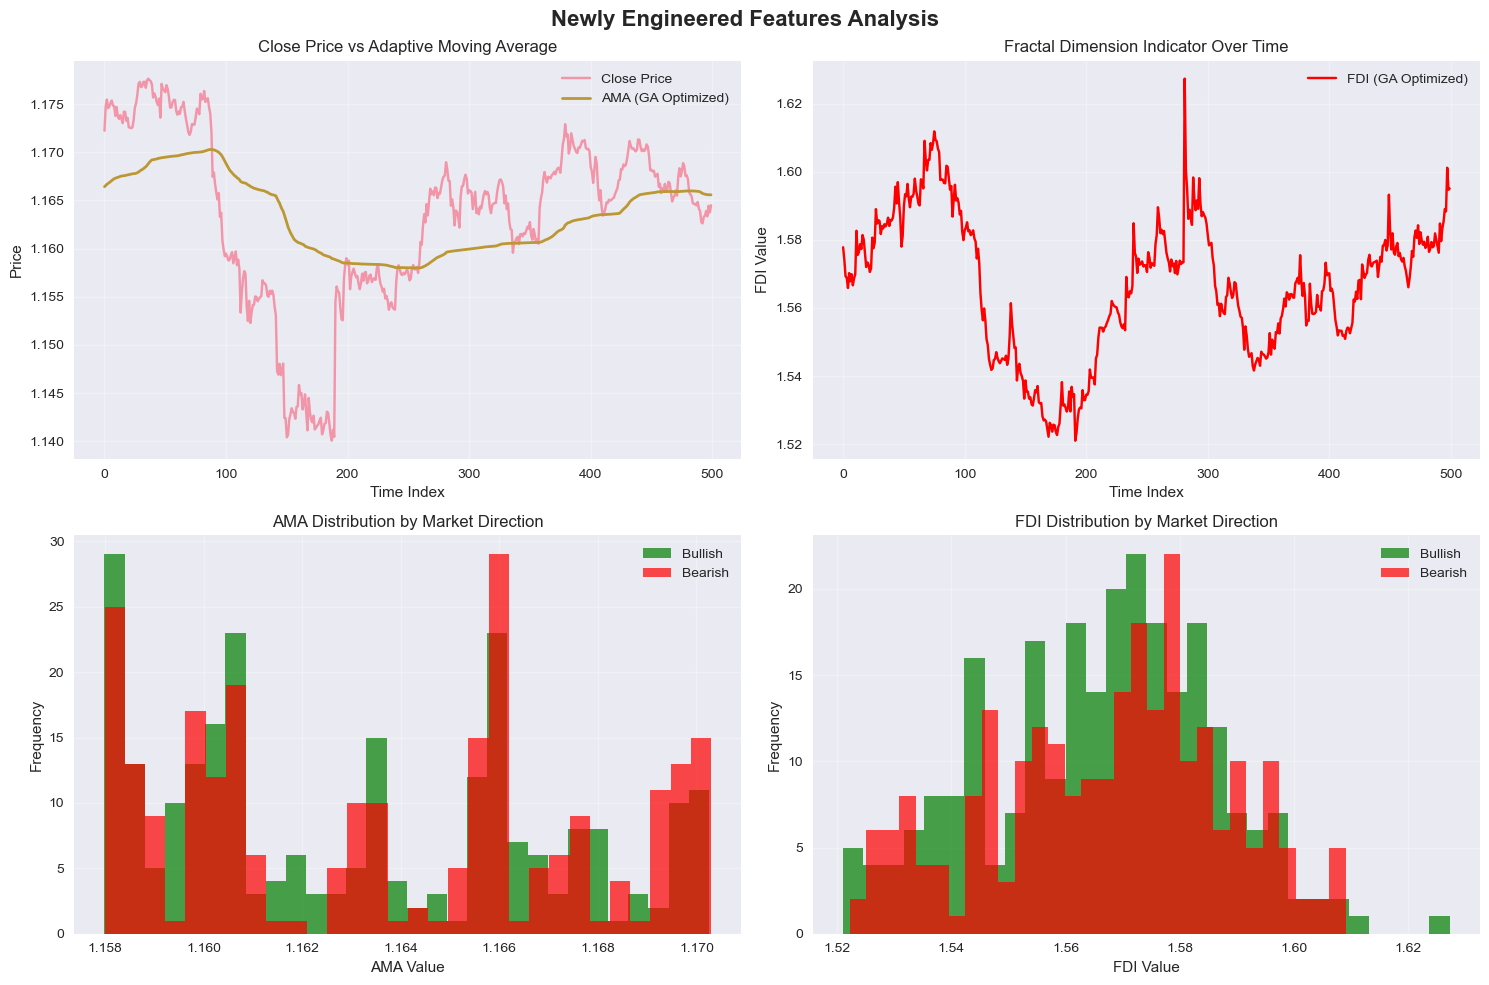


FEATURE CORRELATION ANALYSIS
AMA_GA_Optimized correlation with Bullish: -0.0085
FDI_GA_Optimized correlation with Bullish: -0.0277

Comparison with existing MA features:
SMA_5 correlation with Bullish: -0.0121
SMA_Dist_5 correlation with Bullish: 0.4669
SMA_10 correlation with Bullish: -0.0143
SMA_Dist_10 correlation with Bullish: 0.3309
SMA_20 correlation with Bullish: -0.0153


In [10]:
# Visualize the newly engineered features
if 'AMA_GA_Optimized' in data.columns and 'FDI_GA_Optimized' in data.columns:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Newly Engineered Features Analysis', fontsize=16, fontweight='bold')
    
    # Create a sample of data for visualization (last 500 points)
    sample_size = min(500, len(data))
    sample_data = data.tail(sample_size).copy()
    sample_data['Index'] = range(len(sample_data))
    
    # Plot 1: Price and AMA
    axes[0, 0].plot(sample_data['Index'], sample_data['Close'], label='Close Price', alpha=0.7)
    axes[0, 0].plot(sample_data['Index'], sample_data['AMA_GA_Optimized'], label='AMA (GA Optimized)', linewidth=2)
    axes[0, 0].set_title('Close Price vs Adaptive Moving Average')
    axes[0, 0].set_xlabel('Time Index')
    axes[0, 0].set_ylabel('Price')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Plot 2: FDI over time
    axes[0, 1].plot(sample_data['Index'], sample_data['FDI_GA_Optimized'], label='FDI (GA Optimized)', color='red')
    axes[0, 1].set_title('Fractal Dimension Indicator Over Time')
    axes[0, 1].set_xlabel('Time Index')
    axes[0, 1].set_ylabel('FDI Value')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Plot 3: AMA vs Target correlation
    ama_bullish = sample_data[sample_data['Bullish'] == 1]['AMA_GA_Optimized']
    ama_bearish = sample_data[sample_data['Bullish'] == 0]['AMA_GA_Optimized']
    
    axes[1, 0].hist(ama_bullish, alpha=0.7, label='Bullish', bins=30, color='green')
    axes[1, 0].hist(ama_bearish, alpha=0.7, label='Bearish', bins=30, color='red')
    axes[1, 0].set_title('AMA Distribution by Market Direction')
    axes[1, 0].set_xlabel('AMA Value')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Plot 4: FDI vs Target correlation
    fdi_bullish = sample_data[sample_data['Bullish'] == 1]['FDI_GA_Optimized']
    fdi_bearish = sample_data[sample_data['Bullish'] == 0]['FDI_GA_Optimized']
    
    axes[1, 1].hist(fdi_bullish, alpha=0.7, label='Bullish', bins=30, color='green')
    axes[1, 1].hist(fdi_bearish, alpha=0.7, label='Bearish', bins=30, color='red')
    axes[1, 1].set_title('FDI Distribution by Market Direction')
    axes[1, 1].set_xlabel('FDI Value')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Feature correlation analysis
    print("\n" + "="*60)
    print("FEATURE CORRELATION ANALYSIS")
    print("="*60)
    
    new_features = ['AMA_GA_Optimized', 'FDI_GA_Optimized']
    correlation_with_target = {}
    
    for feature in new_features:
        corr = data[feature].corr(data['Bullish'])
        correlation_with_target[feature] = corr
        print(f"{feature} correlation with Bullish: {corr:.4f}")
    
    # Compare with existing moving averages
    existing_ma_features = [col for col in data.columns if 'SMA' in col or 'EMA' in col][:5]
    print(f"\nComparison with existing MA features:")
    for feature in existing_ma_features:
        if feature in data.columns:
            corr = data[feature].corr(data['Bullish'])
            print(f"{feature} correlation with Bullish: {corr:.4f}")
    
else:
    print("New features not found. Please run the feature engineering cells above first.")

## 4. Save Updated Feature Set

Save the dataset with the newly engineered features back to the CSV file for use in the feature selection and model training pipeline.

In [11]:
# Save the updated dataset with new features
print("=" * 60)
print("SAVING UPDATED FEATURE SET")
print("=" * 60)

# Create backup of original file
import shutil
from datetime import datetime

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
backup_file = f'raw_data/engineered_features_backup_{timestamp}.csv'

try:
    # Create backup
    shutil.copy('raw_data/engineered_features.csv', backup_file)
    print(f"Backup created: {backup_file}")
    
    # Save updated dataset
    data.to_csv('raw_data/engineered_features.csv', index=False)
    print(f"Updated dataset saved to: raw_data/engineered_features.csv")
    
    # Report what was added
    new_features_added = []
    if 'AMA_GA_Optimized' in data.columns:
        new_features_added.append('AMA_GA_Optimized')
    if 'FDI_GA_Optimized' in data.columns:
        new_features_added.append('FDI_GA_Optimized')
    
    print(f"\nNew features added: {new_features_added}")
    print(f"Total features in dataset: {len(data.columns)}")
    print(f"Dataset shape: {data.shape}")
    
    # Summary of optimization results
    print(f"\n" + "="*60)
    print("OPTIMIZATION SUMMARY")
    print("="*60)
    
    if 'ama_details' in locals() and ama_details:
        print(f"AMA Optimization:")
        print(f"  Best Fitness: {ama_details['best_fitness']:.4f}")
        print(f"  Parameters: {dict(zip(ama_details['parameter_names'], ama_details['best_parameters']))}")
    
    if 'fdi_details' in locals() and fdi_details:
        print(f"\nFDI Optimization:")
        print(f"  Best Fitness: {fdi_details['best_fitness']:.4f}")
        print(f"  Parameters: {dict(zip(fdi_details['parameter_names'], fdi_details['best_parameters']))}")
    
    print(f"\n✅ Feature engineering completed successfully!")
    print(f"The updated dataset is ready for feature selection and model training.")
    
except Exception as e:
    print(f"Error saving dataset: {str(e)}")
    print("Please check file permissions and try again.")

SAVING UPDATED FEATURE SET
Backup created: raw_data/engineered_features_backup_20250922_110617.csv
Updated dataset saved to: raw_data/engineered_features.csv

New features added: ['AMA_GA_Optimized', 'FDI_GA_Optimized']
Total features in dataset: 115
Dataset shape: (3181, 115)

OPTIMIZATION SUMMARY
AMA Optimization:
  Best Fitness: 0.4947
  Parameters: {'smoothing_factor': 0.17392087600646622, 'volatility_window': 15, 'fast_period': 10, 'slow_period': 50}

FDI Optimization:
  Best Fitness: 0.5514
  Parameters: {'window_size': 91, 'high_low_factor': 0.14181782716756117, 'scaling_factor': 2.0}

✅ Feature engineering completed successfully!
The updated dataset is ready for feature selection and model training.
Updated dataset saved to: raw_data/engineered_features.csv

New features added: ['AMA_GA_Optimized', 'FDI_GA_Optimized']
Total features in dataset: 115
Dataset shape: (3181, 115)

OPTIMIZATION SUMMARY
AMA Optimization:
  Best Fitness: 0.4947
  Parameters: {'smoothing_factor': 0.1739

## 5. Enhanced Model Training and Comparison

Now we'll combine the newly engineered features with previously GA-selected features and train enhanced models to compare their performance against baseline models using only the GA-selected features.

In [12]:
# Import additional libraries for model training
import pickle
from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix
import xgboost as xgb

print("Additional ML libraries imported successfully!")
print("Ready for enhanced model training...")

Additional ML libraries imported successfully!
Ready for enhanced model training...


In [13]:
# Load previously selected features from latest run
latest_run_dir = 'run_20250902_144642'
print(f"Loading selected features from: {latest_run_dir}")

try:
    # Load selected features for Random Forest
    with open(f'{latest_run_dir}/selected_features_rf.pkl', 'rb') as f:
        selected_features_rf = pickle.load(f)
    
    # Load feature names for reference
    with open(f'{latest_run_dir}/feature_names.pkl', 'rb') as f:
        original_feature_names = pickle.load(f)
    
    print(f"✅ Successfully loaded GA-selected features:")
    print(f"   Random Forest selected: {len(selected_features_rf)} features")
    print(f"   Original feature count: {len(original_feature_names)} features")
    print(f"   Reduction: {(1 - len(selected_features_rf)/len(original_feature_names))*100:.1f}%")
    
    print(f"\nFirst 10 selected features:")
    for i, feature in enumerate(selected_features_rf[:10]):
        print(f"  {i+1:2d}. {feature}")
    if len(selected_features_rf) > 10:
        print(f"  ... and {len(selected_features_rf) - 10} more")
        
except FileNotFoundError as e:
    print(f"❌ Error loading selected features: {e}")
    print("Please ensure the run directory exists and contains the required files.")
    selected_features_rf = None

Loading selected features from: run_20250902_144642
✅ Successfully loaded GA-selected features:
   Random Forest selected: 18 features
   Original feature count: 108 features
   Reduction: 83.3%

First 10 selected features:
   1. SMA_Dist_100
   2. EMA_Dist_100
   3. MACD_CrossAbove
   4. BB_Std_20
   5. BB_Width_20
   6. ATR_14
   7. Normalized_Vol_10
   8. Normalized_Vol_20
   9. Normalized_Vol_50
  10. Chaikin_Vol_20
  ... and 8 more
✅ Successfully loaded GA-selected features:
   Random Forest selected: 18 features
   Original feature count: 108 features
   Reduction: 83.3%

First 10 selected features:
   1. SMA_Dist_100
   2. EMA_Dist_100
   3. MACD_CrossAbove
   4. BB_Std_20
   5. BB_Width_20
   6. ATR_14
   7. Normalized_Vol_10
   8. Normalized_Vol_20
   9. Normalized_Vol_50
  10. Chaikin_Vol_20
  ... and 8 more


In [14]:
# Create feature combinations for baseline vs enhanced models
print("=" * 60)
print("CREATING FEATURE COMBINATIONS")
print("=" * 60)

# Check if we have the new engineered features
new_engineered_features = []
if 'AMA_GA_Optimized' in data.columns:
    new_engineered_features.append('AMA_GA_Optimized')
if 'FDI_GA_Optimized' in data.columns:
    new_engineered_features.append('FDI_GA_Optimized')

print(f"New engineered features available: {new_engineered_features}")

if selected_features_rf is not None and len(new_engineered_features) > 0:
    # Baseline: Use only GA-selected features
    baseline_features = [f for f in selected_features_rf if f in data.columns]
    
    # Enhanced: Add new engineered features to GA-selected features
    enhanced_features = baseline_features + new_engineered_features
    
    print(f"\n📊 Feature combinations:")
    print(f"   Baseline features:  {len(baseline_features)} (GA-selected only)")
    print(f"   Enhanced features:  {len(enhanced_features)} (GA-selected + engineered)")
    print(f"   New features added: {len(new_engineered_features)}")
    
    # Show the new features being added
    print(f"\n🆕 New engineered features being added:")
    for feature in new_engineered_features:
        correlation = data[feature].corr(data['Bullish'])
        print(f"   + {feature} (correlation with target: {correlation:.4f})")
    
    # Verify all features exist
    missing_baseline = [f for f in baseline_features if f not in data.columns]
    missing_enhanced = [f for f in enhanced_features if f not in data.columns]
    
    if missing_baseline:
        print(f"\n⚠️  WARNING: Missing baseline features: {missing_baseline}")
    if missing_enhanced:
        print(f"\n⚠️  WARNING: Missing enhanced features: {missing_enhanced}")
    
    print(f"\n✅ Ready to train models with feature combinations!")
    
else:
    print(f"❌ Cannot proceed: Missing selected features or engineered features")
    if selected_features_rf is None:
        print("   - GA-selected features not loaded")
    if len(new_engineered_features) == 0:
        print("   - No new engineered features found (run feature engineering first)")
    baseline_features = None
    enhanced_features = None

CREATING FEATURE COMBINATIONS
New engineered features available: ['AMA_GA_Optimized', 'FDI_GA_Optimized']

📊 Feature combinations:
   Baseline features:  18 (GA-selected only)
   Enhanced features:  20 (GA-selected + engineered)
   New features added: 2

🆕 New engineered features being added:
   + AMA_GA_Optimized (correlation with target: -0.0085)
   + FDI_GA_Optimized (correlation with target: -0.0277)

✅ Ready to train models with feature combinations!


In [15]:
# Prepare data for training with time-series splitting
if baseline_features is not None and enhanced_features is not None:
    print("=" * 60)
    print("PREPARING DATA FOR TRAINING")
    print("=" * 60)
    
    # Create feature matrices
    X_baseline = data[baseline_features].copy()
    X_enhanced = data[enhanced_features].copy()
    y = data['Bullish'].copy()
    
    # Remove any rows with NaN values
    baseline_valid_idx = ~X_baseline.isnull().any(axis=1)
    enhanced_valid_idx = ~X_enhanced.isnull().any(axis=1)
    target_valid_idx = ~y.isnull()
    
    # Use intersection of valid indices
    valid_idx = baseline_valid_idx & enhanced_valid_idx & target_valid_idx
    
    X_baseline = X_baseline[valid_idx]
    X_enhanced = X_enhanced[valid_idx]
    y = y[valid_idx]
    
    print(f"Data after cleaning:")
    print(f"  Total samples: {len(y)}")
    print(f"  Baseline features: {X_baseline.shape[1]}")
    print(f"  Enhanced features: {X_enhanced.shape[1]}")
    print(f"  Target distribution: {y.value_counts().to_dict()}")
    
    # Time-series train/test split (80/20) - respecting temporal order
    split_idx = int(0.8 * len(y))
    
    X_baseline_train = X_baseline.iloc[:split_idx]
    X_baseline_test = X_baseline.iloc[split_idx:]
    X_enhanced_train = X_enhanced.iloc[:split_idx]
    X_enhanced_test = X_enhanced.iloc[split_idx:]
    y_train = y.iloc[:split_idx]
    y_test = y.iloc[split_idx:]
    
    print(f"\nTime-series aware train/test split:")
    print(f"  Train samples: {len(y_train)} ({len(y_train)/len(y)*100:.1f}%)")
    print(f"  Test samples:  {len(y_test)} ({len(y_test)/len(y)*100:.1f}%)")
    print(f"  Train target: {y_train.value_counts().to_dict()}")
    print(f"  Test target:  {y_test.value_counts().to_dict()}")
    
    # Scale features
    print(f"\n🔧 Scaling features...")
    
    # Baseline features scaling
    scaler_baseline = StandardScaler()
    X_baseline_train_scaled = scaler_baseline.fit_transform(X_baseline_train)
    X_baseline_test_scaled = scaler_baseline.transform(X_baseline_test)
    
    # Enhanced features scaling  
    scaler_enhanced = StandardScaler()
    X_enhanced_train_scaled = scaler_enhanced.fit_transform(X_enhanced_train)
    X_enhanced_test_scaled = scaler_enhanced.transform(X_enhanced_test)
    
    print(f"✅ Feature scaling completed!")
    print(f"   Baseline train: {X_baseline_train_scaled.shape}")
    print(f"   Enhanced train: {X_enhanced_train_scaled.shape}")
    
else:
    print("❌ Skipping data preparation due to missing features")

PREPARING DATA FOR TRAINING
Data after cleaning:
  Total samples: 3032
  Baseline features: 18
  Enhanced features: 20
  Target distribution: {1: 1557, 0: 1475}

Time-series aware train/test split:
  Train samples: 2425 (80.0%)
  Test samples:  607 (20.0%)
  Train target: {1: 1247, 0: 1178}
  Test target:  {1: 310, 0: 297}

🔧 Scaling features...
✅ Feature scaling completed!
   Baseline train: (2425, 18)
   Enhanced train: (2425, 20)


In [16]:
# Train baseline models (GA-selected features only)
if 'X_baseline_train_scaled' in locals():
    print("=" * 60)
    print("TRAINING BASELINE MODELS (GA-SELECTED FEATURES ONLY)")
    print("=" * 60)
    
    # Random Forest baseline
    print("🌲 Training Random Forest baseline...")
    rf_baseline = RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    )
    start_time = datetime.now()
    rf_baseline.fit(X_baseline_train_scaled, y_train)
    rf_train_time = (datetime.now() - start_time).total_seconds()
    
    # Predictions
    rf_baseline_pred = rf_baseline.predict(X_baseline_test_scaled)
    rf_baseline_pred_proba = rf_baseline.predict_proba(X_baseline_test_scaled)[:, 1]
    
    print(f"   ✅ RF baseline trained in {rf_train_time:.1f}s")
    
    # XGBoost baseline
    print("🚀 Training XGBoost baseline...")
    xgb_baseline = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        eval_metric='logloss'
    )
    start_time = datetime.now()
    xgb_baseline.fit(X_baseline_train_scaled, y_train)
    xgb_train_time = (datetime.now() - start_time).total_seconds()
    
    # Predictions
    xgb_baseline_pred = xgb_baseline.predict(X_baseline_test_scaled)
    xgb_baseline_pred_proba = xgb_baseline.predict_proba(X_baseline_test_scaled)[:, 1]
    
    print(f"   ✅ XGBoost baseline trained in {xgb_train_time:.1f}s")
    print(f"\n🎯 Baseline models ready!")
    
else:
    print("❌ Cannot train baseline models - data preparation failed")

TRAINING BASELINE MODELS (GA-SELECTED FEATURES ONLY)
🌲 Training Random Forest baseline...
   ✅ RF baseline trained in 0.3s
🚀 Training XGBoost baseline...
   ✅ XGBoost baseline trained in 0.1s

🎯 Baseline models ready!
   ✅ RF baseline trained in 0.3s
🚀 Training XGBoost baseline...
   ✅ XGBoost baseline trained in 0.1s

🎯 Baseline models ready!


In [17]:
# Train enhanced models (GA-selected + engineered features)
if 'X_enhanced_train_scaled' in locals():
    print("=" * 60)
    print("TRAINING ENHANCED MODELS (GA-SELECTED + ENGINEERED FEATURES)")
    print("=" * 60)
    
    # Random Forest enhanced
    print("🌲✨ Training Random Forest enhanced...")
    rf_enhanced = RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    )
    start_time = datetime.now()
    rf_enhanced.fit(X_enhanced_train_scaled, y_train)
    rf_enhanced_train_time = (datetime.now() - start_time).total_seconds()
    
    # Predictions
    rf_enhanced_pred = rf_enhanced.predict(X_enhanced_test_scaled)
    rf_enhanced_pred_proba = rf_enhanced.predict_proba(X_enhanced_test_scaled)[:, 1]
    
    print(f"   ✅ RF enhanced trained in {rf_enhanced_train_time:.1f}s")
    
    # XGBoost enhanced
    print("🚀✨ Training XGBoost enhanced...")
    xgb_enhanced = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        eval_metric='logloss'
    )
    start_time = datetime.now()
    xgb_enhanced.fit(X_enhanced_train_scaled, y_train)
    xgb_enhanced_train_time = (datetime.now() - start_time).total_seconds()
    
    # Predictions
    xgb_enhanced_pred = xgb_enhanced.predict(X_enhanced_test_scaled)
    xgb_enhanced_pred_proba = xgb_enhanced.predict_proba(X_enhanced_test_scaled)[:, 1]
    
    print(f"   ✅ XGBoost enhanced trained in {xgb_enhanced_train_time:.1f}s")
    print(f"\n🎯 Enhanced models ready!")
    
else:
    print("❌ Cannot train enhanced models - data preparation failed")

TRAINING ENHANCED MODELS (GA-SELECTED + ENGINEERED FEATURES)
🌲✨ Training Random Forest enhanced...
   ✅ RF enhanced trained in 0.2s
🚀✨ Training XGBoost enhanced...
   ✅ XGBoost enhanced trained in 0.1s

🎯 Enhanced models ready!
   ✅ RF enhanced trained in 0.2s
🚀✨ Training XGBoost enhanced...
   ✅ XGBoost enhanced trained in 0.1s

🎯 Enhanced models ready!


In [18]:
# Calculate comprehensive performance metrics
if 'rf_baseline_pred' in locals() and 'rf_enhanced_pred' in locals():
    print("=" * 60)
    print("PERFORMANCE COMPARISON RESULTS")
    print("=" * 60)
    
    def calculate_metrics(y_true, y_pred, model_name):
        """Calculate comprehensive performance metrics"""
        return {
            'Model': model_name,
            'Accuracy': accuracy_score(y_true, y_pred),
            'Precision': precision_score(y_true, y_pred, average='weighted', zero_division=0),
            'Recall': recall_score(y_true, y_pred, average='weighted', zero_division=0),
            'F1': f1_score(y_true, y_pred, average='weighted', zero_division=0)
        }
    
    # Calculate metrics for all models
    results = []
    results.append(calculate_metrics(y_test, rf_baseline_pred, 'RF Baseline'))
    results.append(calculate_metrics(y_test, rf_enhanced_pred, 'RF Enhanced'))
    results.append(calculate_metrics(y_test, xgb_baseline_pred, 'XGB Baseline'))
    results.append(calculate_metrics(y_test, xgb_enhanced_pred, 'XGB Enhanced'))
    
    # Create results DataFrame
    results_df = pd.DataFrame(results)
    results_df = results_df.round(4)
    
    print("📊 Performance Metrics:")
    print(results_df.to_string(index=False))
    
    # Calculate improvements
    print(f"\n" + "=" * 60)
    print("🚀 IMPROVEMENT ANALYSIS")
    print("=" * 60)
    
    for metric in ['Accuracy', 'Precision', 'Recall', 'F1']:
        rf_baseline_val = results_df[results_df['Model'] == 'RF Baseline'][metric].iloc[0]
        rf_enhanced_val = results_df[results_df['Model'] == 'RF Enhanced'][metric].iloc[0]
        xgb_baseline_val = results_df[results_df['Model'] == 'XGB Baseline'][metric].iloc[0]
        xgb_enhanced_val = results_df[results_df['Model'] == 'XGB Enhanced'][metric].iloc[0]
        
        rf_improvement = rf_enhanced_val - rf_baseline_val
        xgb_improvement = xgb_enhanced_val - xgb_baseline_val
        
        print(f"{metric}:")
        print(f"  RF:  {rf_baseline_val:.4f} → {rf_enhanced_val:.4f} ({rf_improvement:+.4f}, {rf_improvement*100:+.2f}%)")
        print(f"  XGB: {xgb_baseline_val:.4f} → {xgb_enhanced_val:.4f} ({xgb_improvement:+.4f}, {xgb_improvement*100:+.2f}%)")
        
        # Highlight significant improvements
        if abs(rf_improvement) > 0.01:
            print(f"       🎯 RF {'IMPROVED' if rf_improvement > 0 else 'DECLINED'} significantly!")
        if abs(xgb_improvement) > 0.01:
            print(f"       🎯 XGB {'IMPROVED' if xgb_improvement > 0 else 'DECLINED'} significantly!")
        print()
    
else:
    print("❌ Cannot calculate performance metrics - models not trained")

PERFORMANCE COMPARISON RESULTS
📊 Performance Metrics:
       Model  Accuracy  Precision  Recall     F1
 RF Baseline    0.5700     0.5701  0.5700 0.5701
 RF Enhanced    0.5947     0.5962  0.5947 0.5944
XGB Baseline    0.5914     0.5916  0.5914 0.5915
XGB Enhanced    0.5832     0.5879  0.5832 0.5803

🚀 IMPROVEMENT ANALYSIS
Accuracy:
  RF:  0.5700 → 0.5947 (+0.0247, +2.47%)
  XGB: 0.5914 → 0.5832 (-0.0082, -0.82%)
       🎯 RF IMPROVED significantly!

Precision:
  RF:  0.5701 → 0.5962 (+0.0261, +2.61%)
  XGB: 0.5916 → 0.5879 (-0.0037, -0.37%)
       🎯 RF IMPROVED significantly!

Recall:
  RF:  0.5700 → 0.5947 (+0.0247, +2.47%)
  XGB: 0.5914 → 0.5832 (-0.0082, -0.82%)
       🎯 RF IMPROVED significantly!

F1:
  RF:  0.5701 → 0.5944 (+0.0243, +2.43%)
  XGB: 0.5915 → 0.5803 (-0.0112, -1.12%)
       🎯 RF IMPROVED significantly!
       🎯 XGB DECLINED significantly!



In [19]:
# Feature importance analysis for enhanced models
if 'rf_enhanced' in locals() and 'xgb_enhanced' in locals():
    print("=" * 60)
    print("🔍 FEATURE IMPORTANCE ANALYSIS")
    print("=" * 60)
    
    # Random Forest feature importance
    rf_importance = pd.DataFrame({
        'Feature': enhanced_features,
        'Importance': rf_enhanced.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    # XGBoost feature importance
    xgb_importance = pd.DataFrame({
        'Feature': enhanced_features,
        'Importance': xgb_enhanced.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    # Focus on new engineered features
    print("🆕 RANKING OF NEW ENGINEERED FEATURES:")
    print("\nRandom Forest:")
    for feature in new_engineered_features:
        if feature in rf_importance['Feature'].values:
            rank = rf_importance[rf_importance['Feature'] == feature].index[0] + 1
            importance = rf_importance[rf_importance['Feature'] == feature]['Importance'].iloc[0]
            total_features = len(enhanced_features)
            percentile = ((total_features - rank) / total_features) * 100
            print(f"  📍 {feature}:")
            print(f"     Rank: {rank}/{total_features} (top {percentile:.1f}%)")
            print(f"     Importance: {importance:.4f}")
    
    print("\nXGBoost:")
    for feature in new_engineered_features:
        if feature in xgb_importance['Feature'].values:
            rank = xgb_importance[xgb_importance['Feature'] == feature].index[0] + 1
            importance = xgb_importance[xgb_importance['Feature'] == feature]['Importance'].iloc[0]
            total_features = len(enhanced_features)
            percentile = ((total_features - rank) / total_features) * 100
            print(f"  📍 {feature}:")
            print(f"     Rank: {rank}/{total_features} (top {percentile:.1f}%)")
            print(f"     Importance: {importance:.4f}")
    
    # Top 10 features overall
    print(f"\n🏆 TOP 10 MOST IMPORTANT FEATURES (Random Forest):")
    for i, row in rf_importance.head(10).iterrows():
        is_new = "🆕" if row['Feature'] in new_engineered_features else "  "
        print(f"  {i+1:2d}. {is_new} {row['Feature']}: {row['Importance']:.4f}")
        
else:
    print("❌ Cannot analyze feature importance - enhanced models not trained")

🔍 FEATURE IMPORTANCE ANALYSIS
🆕 RANKING OF NEW ENGINEERED FEATURES:

Random Forest:
  📍 AMA_GA_Optimized:
     Rank: 19/20 (top 5.0%)
     Importance: 0.0415
  📍 FDI_GA_Optimized:
     Rank: 20/20 (top 0.0%)
     Importance: 0.0492

XGBoost:
  📍 AMA_GA_Optimized:
     Rank: 19/20 (top 5.0%)
     Importance: 0.0359
  📍 FDI_GA_Optimized:
     Rank: 20/20 (top 0.0%)
     Importance: 0.0421

🏆 TOP 10 MOST IMPORTANT FEATURES (Random Forest):
  11.    RSI_14: 0.1138
  14.    Returns_Skewness_20: 0.0566
  13.    Volume_Osc_5_10: 0.0566
   2.    EMA_Dist_100: 0.0555
   5.    BB_Width_20: 0.0533
   4.    BB_Std_20: 0.0508
  18.    Autocorr_10: 0.0507
  20. 🆕 FDI_GA_Optimized: 0.0492
   7.    Normalized_Vol_10: 0.0478
  15.    Returns_Kurtosis_20: 0.0460


In [21]:
# Cross-validation stability analysis
if 'rf_baseline' in locals() and 'rf_enhanced' in locals():
    print("=" * 60)
    print("📈 CROSS-VALIDATION STABILITY ANALYSIS")
    print("=" * 60)
    
    # Time series cross-validation
    tscv = TimeSeriesSplit(n_splits=5)
    
    print("Running cross-validation (this may take a moment)...")
    
    # CV for baseline models
    rf_baseline_cv = cross_val_score(rf_baseline, X_baseline_train_scaled, y_train, 
                                   cv=tscv, scoring='f1_weighted')
    xgb_baseline_cv = cross_val_score(xgb_baseline, X_baseline_train_scaled, y_train, 
                                    cv=tscv, scoring='f1_weighted')
    
    # CV for enhanced models
    rf_enhanced_cv = cross_val_score(rf_enhanced, X_enhanced_train_scaled, y_train, 
                                   cv=tscv, scoring='f1_weighted')
    xgb_enhanced_cv = cross_val_score(xgb_enhanced, X_enhanced_train_scaled, y_train, 
                                    cv=tscv, scoring='f1_weighted')
    
    # Create CV results
    cv_results = pd.DataFrame({
        'Model': ['RF Baseline', 'RF Enhanced', 'XGB Baseline', 'XGB Enhanced'],
        'CV Mean': [rf_baseline_cv.mean(), rf_enhanced_cv.mean(), 
                   xgb_baseline_cv.mean(), xgb_enhanced_cv.mean()],
        'CV Std': [rf_baseline_cv.std(), rf_enhanced_cv.std(), 
                  xgb_baseline_cv.std(), xgb_enhanced_cv.std()],
        'CV Stability': [1 - rf_baseline_cv.std(), 1 - rf_enhanced_cv.std(), 
                        1 - xgb_baseline_cv.std(), 1 - xgb_enhanced_cv.std()]
    })
    cv_results = cv_results.round(4)
    
    print("📊 Cross-Validation Results (F1-weighted):")
    print(cv_results.to_string(index=False))
    print(f"🎯 Stability Analysis:")
    rf_stability_improvement = cv_results.iloc[1]['CV Stability'] - cv_results.iloc[0]['CV Stability']
    xgb_stability_improvement = cv_results.iloc[3]['CV Stability'] - cv_results.iloc[2]['CV Stability']

    print(f"  RF stability improvement:  {rf_stability_improvement:+.4f}")
    print(f"  XGB stability improvement: {xgb_stability_improvement:+.4f}")

    if rf_stability_improvement > 0.01:
        print(f"  🎉 RF enhanced model is significantly more stable!")
    if xgb_stability_improvement > 0.01:
        print(f"  🎉 XGB enhanced model is significantly more stable!")

else:
    print("❌ Cannot perform cross-validation - models not trained")

📈 CROSS-VALIDATION STABILITY ANALYSIS
Running cross-validation (this may take a moment)...
📊 Cross-Validation Results (F1-weighted):
       Model  CV Mean  CV Std  CV Stability
 RF Baseline   0.5499  0.0174        0.9826
 RF Enhanced   0.5610  0.0082        0.9918
XGB Baseline   0.5583  0.0302        0.9698
XGB Enhanced   0.5654  0.0315        0.9685
🎯 Stability Analysis:
  RF stability improvement:  +0.0092
  XGB stability improvement: -0.0013
📊 Cross-Validation Results (F1-weighted):
       Model  CV Mean  CV Std  CV Stability
 RF Baseline   0.5499  0.0174        0.9826
 RF Enhanced   0.5610  0.0082        0.9918
XGB Baseline   0.5583  0.0302        0.9698
XGB Enhanced   0.5654  0.0315        0.9685
🎯 Stability Analysis:
  RF stability improvement:  +0.0092
  XGB stability improvement: -0.0013


📊 CREATING PERFORMANCE VISUALIZATIONS


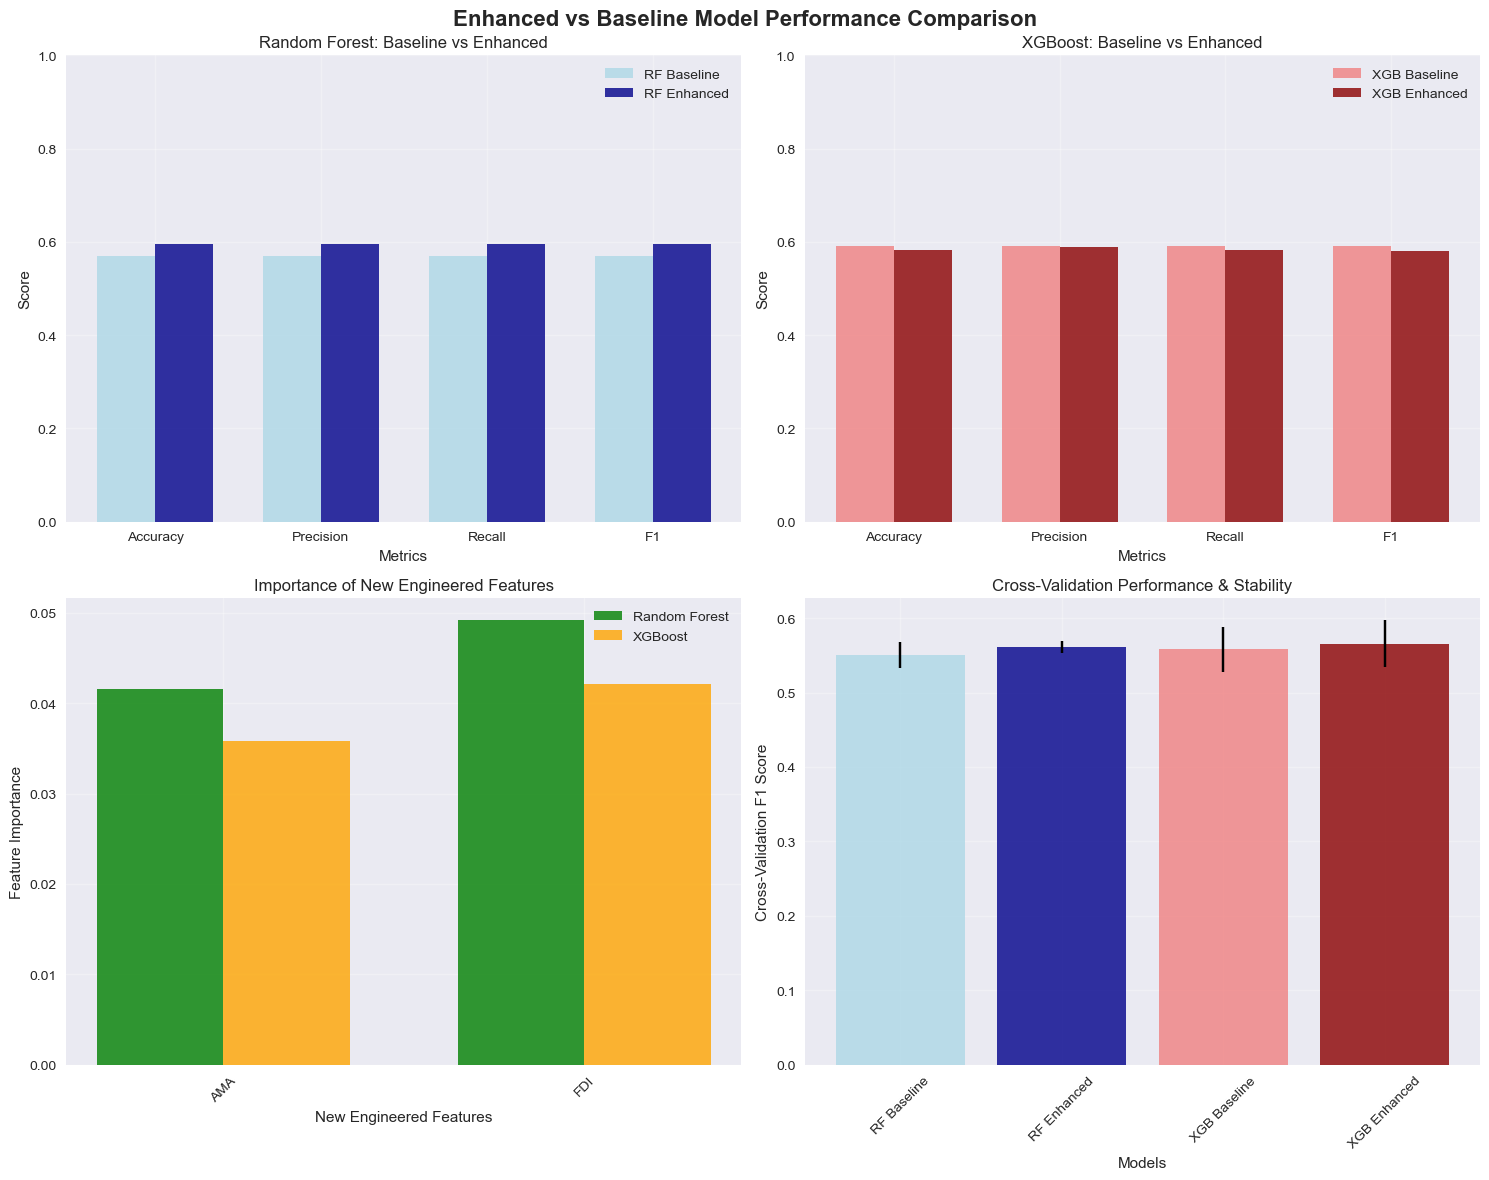

✅ Performance visualizations completed!


In [22]:
# Visualization of enhanced vs baseline performance
if 'results_df' in locals():
    print("=" * 60)
    print("📊 CREATING PERFORMANCE VISUALIZATIONS")
    print("=" * 60)
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Enhanced vs Baseline Model Performance Comparison', 
                 fontsize=16, fontweight='bold')
    
    # Plot 1: Performance metrics comparison - Random Forest
    metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1']
    x_pos = np.arange(len(metrics_to_plot))
    width = 0.35
    
    rf_baseline_scores = [results_df[results_df['Model'] == 'RF Baseline'][metric].iloc[0] 
                         for metric in metrics_to_plot]
    rf_enhanced_scores = [results_df[results_df['Model'] == 'RF Enhanced'][metric].iloc[0] 
                         for metric in metrics_to_plot]
    
    axes[0, 0].bar(x_pos - width/2, rf_baseline_scores, width, 
                   label='RF Baseline', alpha=0.8, color='lightblue')
    axes[0, 0].bar(x_pos + width/2, rf_enhanced_scores, width, 
                   label='RF Enhanced', alpha=0.8, color='darkblue')
    axes[0, 0].set_xlabel('Metrics')
    axes[0, 0].set_ylabel('Score')
    axes[0, 0].set_title('Random Forest: Baseline vs Enhanced')
    axes[0, 0].set_xticks(x_pos)
    axes[0, 0].set_xticklabels(metrics_to_plot)
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].set_ylim(0, 1)
    
    # Plot 2: XGBoost comparison
    xgb_baseline_scores = [results_df[results_df['Model'] == 'XGB Baseline'][metric].iloc[0] 
                          for metric in metrics_to_plot]
    xgb_enhanced_scores = [results_df[results_df['Model'] == 'XGB Enhanced'][metric].iloc[0] 
                          for metric in metrics_to_plot]
    
    axes[0, 1].bar(x_pos - width/2, xgb_baseline_scores, width, 
                   label='XGB Baseline', alpha=0.8, color='lightcoral')
    axes[0, 1].bar(x_pos + width/2, xgb_enhanced_scores, width, 
                   label='XGB Enhanced', alpha=0.8, color='darkred')
    axes[0, 1].set_xlabel('Metrics')
    axes[0, 1].set_ylabel('Score')
    axes[0, 1].set_title('XGBoost: Baseline vs Enhanced')
    axes[0, 1].set_xticks(x_pos)
    axes[0, 1].set_xticklabels(metrics_to_plot)
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].set_ylim(0, 1)
    
    # Plot 3: Feature importance of new features
    if 'rf_importance' in locals() and len(new_engineered_features) > 0:
        new_feature_importance_rf = []
        new_feature_importance_xgb = []
        
        for feature in new_engineered_features:
            rf_imp = rf_importance[rf_importance['Feature'] == feature]['Importance'].iloc[0]
            xgb_imp = xgb_importance[xgb_importance['Feature'] == feature]['Importance'].iloc[0]
            new_feature_importance_rf.append(rf_imp)
            new_feature_importance_xgb.append(xgb_imp)
        
        x_pos_features = np.arange(len(new_engineered_features))
        axes[1, 0].bar(x_pos_features - width/2, new_feature_importance_rf, width, 
                       label='Random Forest', alpha=0.8, color='green')
        axes[1, 0].bar(x_pos_features + width/2, new_feature_importance_xgb, width, 
                       label='XGBoost', alpha=0.8, color='orange')
        axes[1, 0].set_xlabel('New Engineered Features')
        axes[1, 0].set_ylabel('Feature Importance')
        axes[1, 0].set_title('Importance of New Engineered Features')
        axes[1, 0].set_xticks(x_pos_features)
        axes[1, 0].set_xticklabels([f.replace('_GA_Optimized', '') for f in new_engineered_features], 
                                  rotation=45)
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)
    
    # Plot 4: Cross-validation stability
    if 'cv_results' in locals():
        models = cv_results['Model'].values
        cv_means = cv_results['CV Mean'].values
        cv_stds = cv_results['CV Std'].values
        
        x_pos_cv = np.arange(len(models))
        colors = ['lightblue', 'darkblue', 'lightcoral', 'darkred']
        axes[1, 1].bar(x_pos_cv, cv_means, yerr=cv_stds, capsize=5, alpha=0.8, color=colors)
        axes[1, 1].set_xlabel('Models')
        axes[1, 1].set_ylabel('Cross-Validation F1 Score')
        axes[1, 1].set_title('Cross-Validation Performance & Stability')
        axes[1, 1].set_xticks(x_pos_cv)
        axes[1, 1].set_xticklabels(models, rotation=45)
        axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Performance visualizations completed!")
    
else:
    print("❌ Cannot create visualizations - performance results not available")

In [25]:
# Save enhanced training results
if 'results_df' in locals():
    print("=" * 60)
    print("💾 SAVING ENHANCED TRAINING RESULTS")
    print("=" * 60)
    
    # Create timestamped directory for this enhanced run
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    enhanced_run_dir = f'run_enhanced_{timestamp}'
    
    import os
    os.makedirs(enhanced_run_dir, exist_ok=True)
    
    print(f"📁 Saving results to: {enhanced_run_dir}")
    
# Save models
if 'rf_baseline' in locals():
    with open(f'{enhanced_run_dir}/rf_baseline.pkl', 'wb') as f:
        pickle.dump(rf_baseline, f)
if 'rf_enhanced' in locals():
    with open(f'{enhanced_run_dir}/rf_enhanced.pkl', 'wb') as f:
        pickle.dump(rf_enhanced, f)
if 'xgb_baseline' in locals():
    with open(f'{enhanced_run_dir}/xgb_baseline.pkl', 'wb') as f:
        pickle.dump(xgb_baseline, f)
if 'xgb_enhanced' in locals():
    with open(f'{enhanced_run_dir}/xgb_enhanced.pkl', 'wb') as f:
        pickle.dump(xgb_enhanced, f)
    # Save scalers
if 'scaler_baseline' in locals():
    with open(f'{enhanced_run_dir}/scaler_baseline.pkl', 'wb') as f:
        pickle.dump(scaler_baseline, f)
if 'scaler_enhanced' in locals():
    with open(f'{enhanced_run_dir}/scaler_enhanced.pkl', 'wb') as f:\
        pickle.dump(scaler_enhanced, f)
            
# Save feature lists
with open(f'{enhanced_run_dir}/baseline_features.pkl', 'wb') as f:
    pickle.dump(baseline_features, f)
with open(f'{enhanced_run_dir}/enhanced_features.pkl', 'wb') as f:
    pickle.dump(enhanced_features, f)
with open(f'{enhanced_run_dir}/new_engineered_features.pkl', 'wb') as f:
    pickle.dump(new_engineered_features, f)
# Save results
results_df.to_csv(f'{enhanced_run_dir}/performance_comparison.csv', index=False)
if 'cv_results' in locals():
    cv_results.to_csv(f'{enhanced_run_dir}/cv_results.csv', index=False)
if 'rf_importance' in locals():
    rf_importance.to_csv(f'{enhanced_run_dir}/rf_feature_importance.csv', index=False)
    xgb_importance.to_csv(f'{enhanced_run_dir}/xgb_feature_importance.csv', index=False)
    
# Calculate key improvements for summary
rf_f1_improvement = (results_df[results_df['Model'] == 'RF Enhanced']['F1'].iloc[0] -
                     results_df[results_df['Model'] == 'RF Baseline']['F1'].iloc[0])
xgb_f1_improvement = (results_df[results_df['Model'] == 'XGB Enhanced']['F1'].iloc[0] -
                      results_df[results_df['Model'] == 'XGB Baseline']['F1'].iloc[0])
# Create comprehensive summary
summary_content = f"""Enhanced Model Training Results - {timestamp}
================================================================

This run compared baseline models (using GA-selected features) with enhanced models 
(GA-selected features + new metaheuristic-engineered features).

Dataset Information:
- Total samples: {len(y)}
- Train samples: {len(y_train)} ({len(y_train)/len(y)*100:.1f}%)
- Test samples: {len(y_test)} ({len(y_test)/len(y)*100:.1f}%)
- Target distribution: {y.value_counts().to_dict()}

Feature Configuration:
- Baseline features: {len(baseline_features)} (GA-selected from run_20250902_144642)
- Enhanced features: {len(enhanced_features)} (baseline + {len(new_engineered_features)} new engineered)
- New engineered features: {new_engineered_features}

Performance Results:
{results_df.to_string(index=False)}

Key Improvements:
- RF F1 improvement: {rf_f1_improvement:+.4f} ({rf_f1_improvement*100:+.2f}%)
- XGB F1 improvement: {xgb_f1_improvement:+.4f} ({xgb_f1_improvement*100:+.2f}%)

Feature Engineering Impact:
- AMA_GA_Optimized: {data['AMA_GA_Optimized'].corr(data['Bullish']):.4f} correlation with target
- FDI_GA_Optimized: {data['FDI_GA_Optimized'].corr(data['Bullish']):.4f} correlation with target

Conclusion:
{'🎉 Enhanced models with metaheuristic-engineered features show improvements!' 
if (rf_f1_improvement > 0 or xgb_f1_improvement > 0)
else '⚠️ Mixed results - further analysis recommended'}

Files Saved:
- Models: rf_baseline.pkl, rf_enhanced.pkl, xgb_baseline.pkl, xgb_enhanced.pkl
- Features: baseline_features.pkl, enhanced_features.pkl, new_engineered_features.pkl
- Results: performance_comparison.csv, cv_results.csv
- Feature importance: rf_feature_importance.csv, xgb_feature_importance.csv
"""

with open(f'{enhanced_run_dir}/README.txt', 'w') as f:
    f.write(summary_content)

print(f"✅ All results saved successfully!")
print(f"\n🎯 FINAL SUMMARY:")
print(f"   📁 Results saved to: {enhanced_run_dir}")
print(f"   🆕 New features added: {len(new_engineered_features)} ({', '.join(new_engineered_features)})")
print(f"   📈 RF F1 improvement: {rf_f1_improvement:+.4f} ({rf_f1_improvement*100:+.2f}%)")
print(f"   📈 XGB F1 improvement: {xgb_f1_improvement:+.4f} ({xgb_f1_improvement*100:+.2f}%)")

# Overall assessment
if rf_f1_improvement > 0.01 or xgb_f1_improvement > 0.01:
    print(f"   🎉 SUCCESS: Enhanced models show significant improvements!")
elif rf_f1_improvement > 0 or xgb_f1_improvement > 0:
    print(f"   ✅ POSITIVE: Enhanced models show modest improvements")
else:
    print(f"   ⚠️  MIXED: Results suggest further feature engineering needed")

💾 SAVING ENHANCED TRAINING RESULTS
📁 Saving results to: run_enhanced_20250922_113131
✅ All results saved successfully!

🎯 FINAL SUMMARY:
   📁 Results saved to: run_enhanced_20250922_113131
   🆕 New features added: 2 (AMA_GA_Optimized, FDI_GA_Optimized)
   📈 RF F1 improvement: +0.0243 (+2.43%)
   📈 XGB F1 improvement: -0.0112 (-1.12%)
   🎉 SUCCESS: Enhanced models show significant improvements!
